In [16]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model_name= 'llama-3.3-70b-versatile',
    temperature= 0.7
)

In [12]:
class FindSentiment(BaseModel):
    response: Annotated[Literal['Possitive', 'Negative'], Field(..., description="Give the feedback of this review")]

feedback_model = model.with_structured_output(FindSentiment)

feedback_model.invoke("This is very bad smart phone")

FindSentiment(response='Negative')

In [13]:
class DiagnosisSchema(BaseModel):
    issue_type: Annotated[Literal['UX', 'Performance', 'Bug', 'Support', 'Other'], Field(..., description='The category of issue mentioned in the review')]
    tone: Annotated[Literal['angry', 'frustated', 'disappointed', 'calm'], Field(..., description='The emotional tone expressed by the user')]
    urgency: Annotated[Literal['low', 'medium', 'high'], Field(..., description="How much urgent the issue is ")]

diagnosis_model = model.with_structured_output(DiagnosisSchema)

diagnosis_model.invoke("This is very bad smart phone")

DiagnosisSchema(issue_type='Performance', tone='angry', urgency='high')

In [15]:
class ReviewState(TypedDict):
    review: str
    feedback: Literal['Possitive', 'Negative']
    diagnosis: dict
    final_response: str


In [17]:
def find_sentiment(state: ReviewState):
    prompt = f"Give the sentiment of the review: {state['review']}" 
    response = feedback_model.invoke(prompt).response
    return {'feedback': response}

In [18]:
def run_diagnosis(state: ReviewState):
    prompt = f"Give issue type, tone and urgency of this negative feedback: {state['review']}"
    diagnosis = diagnosis_model.invoke(prompt)

    return {'diagnosis' : diagnosis}

In [20]:
def possitive_response(state: ReviewState):
    prompt = f"Give possitive response about the posstive review: {state['review']}"
    response = model.invoke(prompt).content

    return {'final_response': response}

In [21]:
def negative_response(state: ReviewState):
    prompt = f"Give  response about the Negative review: {state['review']}, having  {state['diagnosis']}"
    response = model.invoke(prompt).content

    return {'final_response': response}

In [23]:
def check_condition(state: ReviewState) -> Literal['run_diagnosis', 'possitive_response']:

    if state['feedback'] == 'Possitive':
        return 'possitive_response'
    else:
        return 'run_diagnosis'

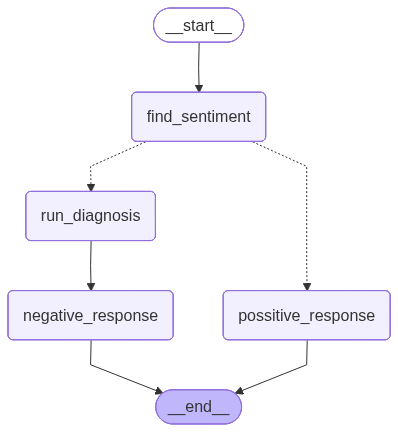

In [26]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('possitive_response', possitive_response)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_condition)

graph.add_edge('possitive_response', END)

graph.add_edge('run_diagnosis', 'negative_response' )
graph.add_edge('negative_response', END)



workflow = graph.compile()

workflow

In [27]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'feedback': 'Negative',
 'diagnosis': DiagnosisSchema(issue_type='Bug', tone='angry', urgency='high'),
 'final_response': "I apologize for the frustrating experience you're having with our app. We understand that being unable to log in due to freezing on the authentication screen is not only inconvenient but also unacceptable, especially when it impacts basic functionality. \n\nWe take issues like this very seriously, and I want to assure you that we're immediately looking into the matter. Given the nature of the problem and its impact on your ability to use our app, we classify this as a high-urgency bug that requires prompt attention.\n\nTo help us resolve this issue as quickly as possible, could you please provide us with more details? This 